# Phase 4: Streamlit Dashboard Development

This notebook develops and validates the dashboard logic before it is promoted to `app.py`.

Unlike the previous notebooks, this one is not meant to be run top to bottom in one go. Each section corresponds to a dashboard component. We validate the data and chart logic here, then the working code goes directly into `app.py` as a Streamlit application.

**Dashboard sections:**
1. Data loading layer — reusable functions that `app.py` will import
2. Price history chart — nominal vs real prices over time
3. Inflation impact chart — how much inflation added to each era
4. Publisher comparison — pricing strategy by publisher
5. Premium edition analysis — base vs premium gap over time
6. The prediction — GTA VI price with confidence interval
7. Take-Two financial context — revenue growth alongside pricing shift

**Output:** Validated chart logic ready to be written into `app.py`

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import os
import sys
from dotenv import load_dotenv
from urllib.parse import quote_plus
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error

sys.path.append(os.path.abspath('..'))
load_dotenv(dotenv_path='../.env')

print('Imports successful')

Imports successful


In [2]:
def get_engine():
    password = quote_plus(os.getenv('DB_PASSWORD'))
    return create_engine(
        f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{password}"
        f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
    )

def load_master_data():
    engine = get_engine()
    return pd.read_sql("SELECT * FROM master_dataset ORDER BY release_year", engine)

def load_cpi_data():
    engine = get_engine()
    return pd.read_sql("SELECT year, annual_cpi FROM cpi_data ORDER BY year", engine)

def load_financials():
    engine = get_engine()
    return pd.read_sql("""
        SELECT fiscal_year, total_revenue_usd_millions,
               gross_margin_pct, net_income_usd_millions
        FROM taketwo_financials
        ORDER BY fiscal_year
    """, engine)

df = load_master_data()
df_cpi = load_cpi_data()
df_fin = load_financials()

print(f"Master dataset: {len(df)} records")
print(f"CPI data: {len(df_cpi)} records")
print(f"Financials: {len(df_fin)} records")

Master dataset: 42 records
CPI data: 26 records
Financials: 14 records


## 2. Run the Model

Reproduce the model from Phase 3 so the dashboard has live predictions.

In [3]:
def train_model(df):
    """
    Train the linear regression model and return predictions for GTA VI.
    This function is self-contained so app.py can call it directly.
    """
    features = ['release_year', 'platform_generation', 'inflation_multiplier', 'had_premium_edition']
    target = 'base_price_real'

    X = df[features]
    y = df[target]

    model = LinearRegression()
    model.fit(X, y)

    # LOO for MAE
    loo = LeaveOneOut()
    preds, actuals = [], []
    for train_idx, test_idx in loo.split(X.values):
        m = LinearRegression()
        m.fit(X.values[train_idx], y.values[train_idx])
        preds.append(m.predict(X.values[test_idx])[0])
        actuals.append(y.values[test_idx][0])
    mae = mean_absolute_error(actuals, preds)

    return model, mae

def predict_gtavi(model, mae, df_cpi):
    """Generate GTA VI price prediction."""
    recent = df_cpi.tail(5)
    avg_growth = (
        (recent['annual_cpi'].iloc[-1] / recent['annual_cpi'].iloc[0])
        ** (1 / (len(recent) - 1)) - 1
    )
    cpi_2025 = df_cpi.loc[df_cpi['year'] == 2025, 'annual_cpi'].values[0]
    cpi_2026 = cpi_2025 * (1 + avg_growth)
    multiplier_2026 = round(cpi_2025 / cpi_2026, 4)

    X_pred = np.array([[2026, 3, multiplier_2026, 1]])
    pred_real = model.predict(X_pred)[0]
    pred_nominal = round(pred_real / multiplier_2026, 2)
    mae_nominal = round(mae / multiplier_2026, 2)

    gen3_premium = df[
        (df['platform_generation'] == 3) &
        (df['had_premium_edition'] == 1) &
        (df['premium_price_nominal'].notna())
    ].copy()
    avg_gap = (gen3_premium['premium_price_nominal'] - gen3_premium['base_price_nominal']).mean()
    pred_premium = round(pred_nominal + avg_gap, 2)

    return {
        'pred_real': round(pred_real, 2),
        'pred_nominal': pred_nominal,
        'pred_premium': pred_premium,
        'mae_nominal': mae_nominal,
        'low': round(pred_nominal - mae_nominal, 2),
        'high': round(pred_nominal + mae_nominal, 2),
        'cpi_2026': round(cpi_2026, 3),
        'multiplier_2026': multiplier_2026
    }

model, mae = train_model(df)
prediction = predict_gtavi(model, mae, df_cpi)

print(f"Base price prediction:    ${prediction['pred_nominal']}")
print(f"Premium price prediction: ${prediction['pred_premium']}")
print(f"Confidence range:         ${prediction['low']} - ${prediction['high']}")

Base price prediction:    $69.72
Premium price prediction: $93.05
Confidence range:         $67.37 - $72.07


/Users/seleteakpotosu-nartey/anaconda3/envs/gtavi-economy-map/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 3. Chart 1 — Nominal vs Real Price History

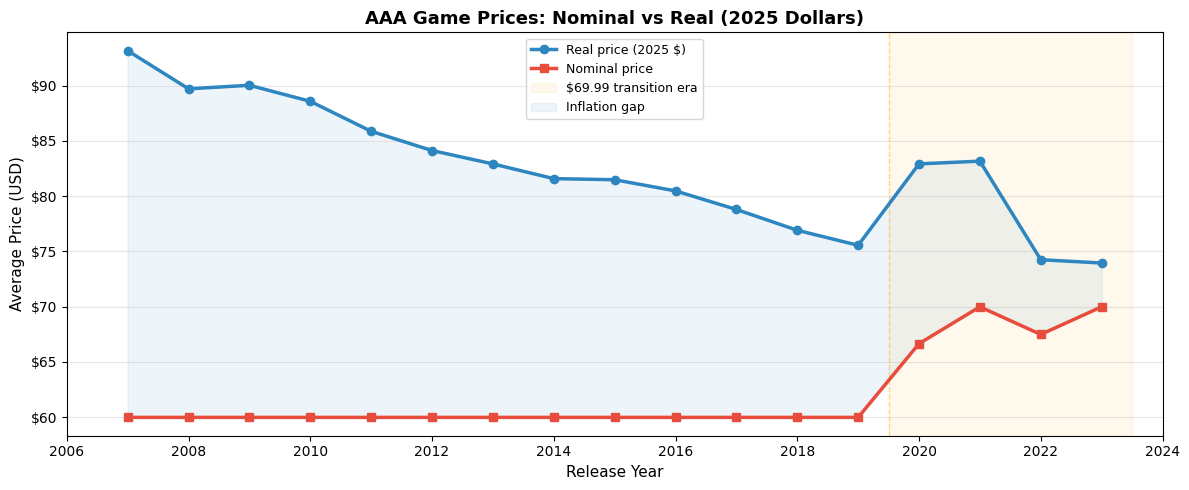

Chart 1 validated


In [4]:
def chart_price_history(df):
    avg_real = df.groupby('release_year')['base_price_real'].mean()
    avg_nominal = df.groupby('release_year')['base_price_nominal'].mean()
    years = sorted(df['release_year'].unique())

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(years, [avg_real[y] for y in years],
            color='#2E86C1', linewidth=2.5, marker='o', markersize=6,
            label='Real price (2025 $)', zorder=3)
    ax.plot(years, [avg_nominal[y] for y in years],
            color='#E74C3C', linewidth=2.5, marker='s', markersize=6,
            label='Nominal price', zorder=3)

    ax.axvspan(2019.5, 2023.5, alpha=0.07, color='orange', label='$69.99 transition era')
    ax.axvline(x=2019.5, color='orange', linestyle='--', alpha=0.4, linewidth=1)

    ax.fill_between(years,
                    [avg_nominal[y] for y in years],
                    [avg_real[y] for y in years],
                    alpha=0.08, color='#2E86C1', label='Inflation gap')

    ax.set_xlabel('Release Year', fontsize=11)
    ax.set_ylabel('Average Price (USD)', fontsize=11)
    ax.set_title('AAA Game Prices: Nominal vs Real (2025 Dollars)', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(2006, 2024)

    plt.tight_layout()
    plt.savefig('../data/processed/chart_price_history.png', dpi=150, bbox_inches='tight')
    plt.show()

chart_price_history(df)
print("Chart 1 validated")

## 4. Chart 2 — Inflation Impact by Era

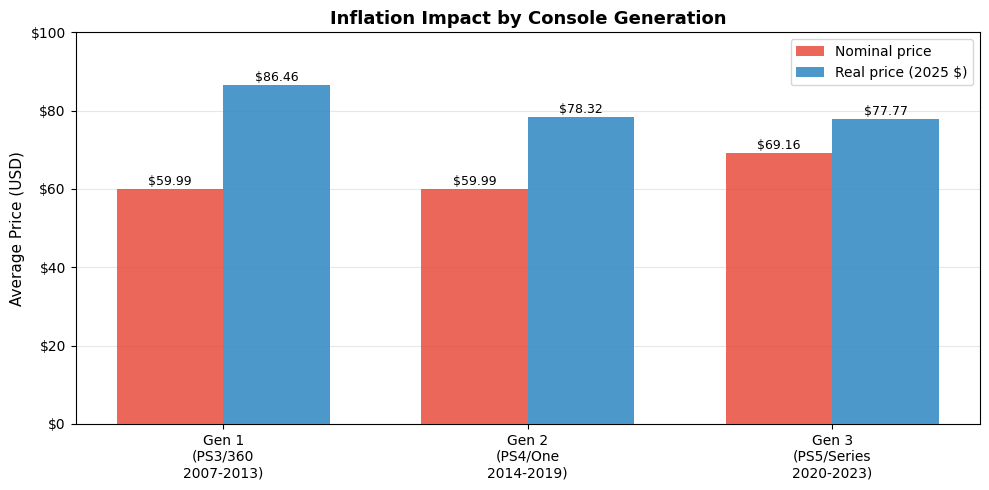

Inflation added per generation (real - nominal):
  Gen 1: +$26.47 in real purchasing power
  Gen 2: +$18.33 in real purchasing power
  Gen 3: +$8.61 in real purchasing power
Chart 2 validated


In [5]:
def chart_inflation_impact(df):
    df_copy = df.copy()
    df_copy['inflation_added'] = df_copy['base_price_real'] - df_copy['base_price_nominal']

    gen_labels = {1: 'Gen 1\n(PS3/360\n2007-2013)',
                  2: 'Gen 2\n(PS4/One\n2014-2019)',
                  3: 'Gen 3\n(PS5/Series\n2020-2023)'}

    gen_avg = df_copy.groupby('platform_generation').agg(
        avg_nominal=('base_price_nominal', 'mean'),
        avg_real=('base_price_real', 'mean'),
        avg_inflation_added=('inflation_added', 'mean')
    ).round(2)

    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(3)
    w = 0.35

    bars1 = ax.bar(x - w/2, gen_avg['avg_nominal'],
                   width=w, color='#E74C3C', alpha=0.85, label='Nominal price', zorder=3)
    bars2 = ax.bar(x + w/2, gen_avg['avg_real'],
                   width=w, color='#2E86C1', alpha=0.85, label='Real price (2025 $)', zorder=3)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'${bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'${bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([gen_labels[g] for g in gen_avg.index], fontsize=10)
    ax.set_ylabel('Average Price (USD)', fontsize=11)
    ax.set_title('Inflation Impact by Console Generation', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.savefig('../data/processed/chart_inflation_impact.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Inflation added per generation (real - nominal):")
    for gen, row in gen_avg.iterrows():
        print(f"  Gen {gen}: +${row['avg_inflation_added']:.2f} in real purchasing power")

chart_inflation_impact(df)
print("Chart 2 validated")

## 5. Chart 3 — Publisher Pricing Comparison

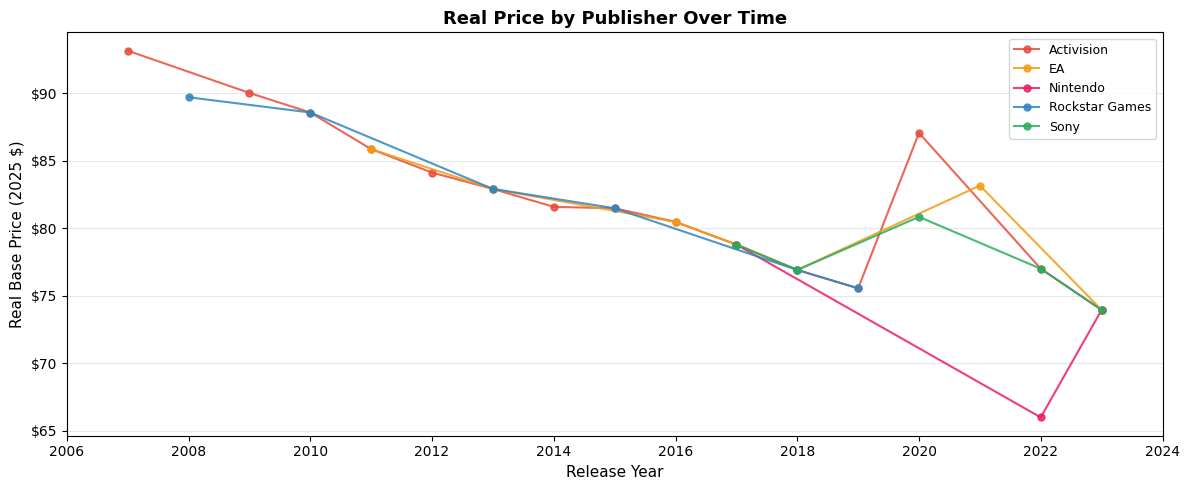

Chart 3 validated


In [6]:
def chart_publisher_comparison(df):
    publisher_year = df.groupby(['publisher', 'release_year'])['base_price_real'].mean().reset_index()

    publishers = sorted(df['publisher'].unique())
    colors = {
        'Activision':     '#E74C3C',
        'EA':             '#F39C12',
        'Nintendo':       '#E91E63',
        'Rockstar Games': '#2E86C1',
        'Sony':           '#27AE60'
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    for pub in publishers:
        pub_data = publisher_year[publisher_year['publisher'] == pub].sort_values('release_year')
        ax.plot(pub_data['release_year'], pub_data['base_price_real'],
                color=colors.get(pub, 'gray'), linewidth=1.5,
                marker='o', markersize=5, label=pub, alpha=0.85)

    ax.set_xlabel('Release Year', fontsize=11)
    ax.set_ylabel('Real Base Price (2025 $)', fontsize=11)
    ax.set_title('Real Price by Publisher Over Time', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(2006, 2024)

    plt.tight_layout()
    plt.savefig('../data/processed/chart_publisher_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

chart_publisher_comparison(df)
print("Chart 3 validated")

## 6. Chart 4 — Premium Edition Gap Over Time

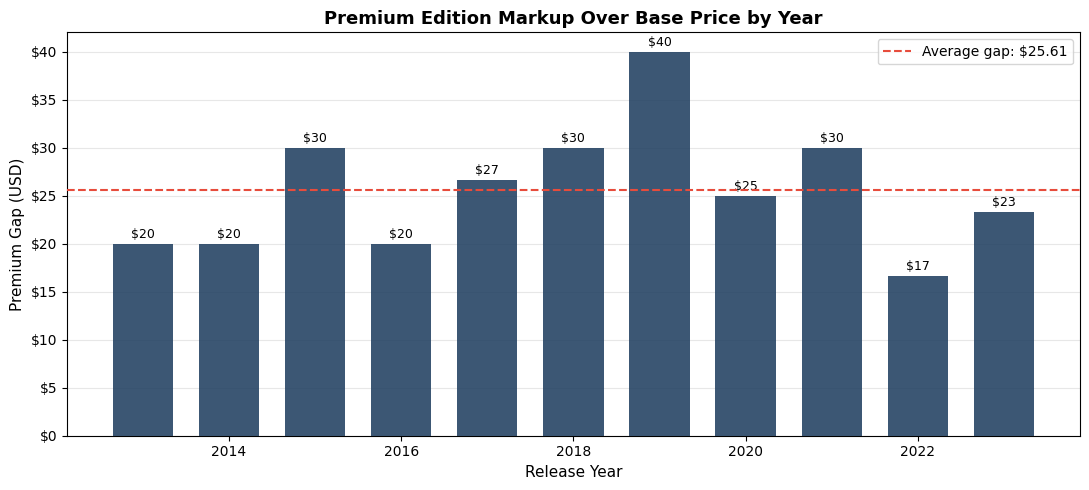

Chart 4 validated


In [7]:
def chart_premium_gap(df):
    premium = df[
        (df['had_premium_edition'] == 1) &
        (df['premium_price_nominal'].notna())
    ].copy()
    premium['gap_nominal'] = premium['premium_price_nominal'] - premium['base_price_nominal']

    avg_gap = premium.groupby('release_year')['gap_nominal'].mean().round(2)

    fig, ax = plt.subplots(figsize=(11, 5))

    bars = ax.bar(avg_gap.index, avg_gap.values,
                  color='#1A3A5C', alpha=0.85, width=0.7, zorder=3)

    for bar, val in zip(bars, avg_gap.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'${val:.0f}', ha='center', va='bottom', fontsize=9)

    ax.axhline(y=avg_gap.mean(), color='#E74C3C', linestyle='--',
               linewidth=1.5, label=f'Average gap: ${avg_gap.mean():.2f}', zorder=4)

    ax.set_xlabel('Release Year', fontsize=11)
    ax.set_ylabel('Premium Gap (USD)', fontsize=11)
    ax.set_title('Premium Edition Markup Over Base Price by Year', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../data/processed/chart_premium_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

chart_premium_gap(df)
print("Chart 4 validated")

## 7. Chart 5 — The GTA VI Prediction

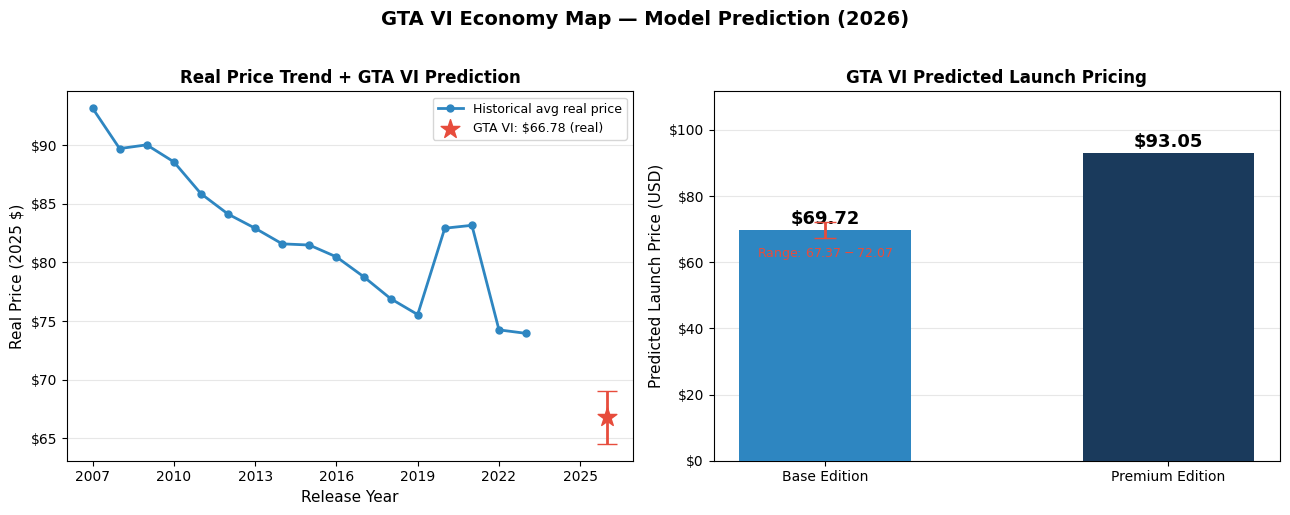

Chart 5 validated


In [8]:
def chart_prediction(df, prediction):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left — real price trend with prediction
    ax1 = axes[0]
    avg_real = df.groupby('release_year')['base_price_real'].mean()
    years = sorted(df['release_year'].unique())

    ax1.plot(years, [avg_real[y] for y in years],
             color='#2E86C1', linewidth=2, marker='o', markersize=5,
             label='Historical avg real price', zorder=3)

    ax1.scatter([2026], [prediction['pred_real']],
                color='#E74C3C', s=200, zorder=5, marker='*',
                label=f"GTA VI: ${prediction['pred_real']:.2f} (real)")
    ax1.errorbar([2026], [prediction['pred_real']], yerr=mae,
                 fmt='none', color='#E74C3C', capsize=7, linewidth=2, zorder=4)

    ax1.set_xlabel('Release Year', fontsize=11)
    ax1.set_ylabel('Real Price (2025 $)', fontsize=11)
    ax1.set_title('Real Price Trend + GTA VI Prediction', fontweight='bold')
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

    # Right — predicted editions
    ax2 = axes[1]
    editions = ['Base Edition', 'Premium Edition']
    prices = [prediction['pred_nominal'], prediction['pred_premium']]
    bar_colors = ['#2E86C1', '#1A3A5C']

    bars = ax2.bar(editions, prices, color=bar_colors, width=0.5, zorder=3)
    ax2.errorbar(['Base Edition'], [prediction['pred_nominal']],
                 yerr=prediction['mae_nominal'],
                 fmt='none', color='#E74C3C', capsize=8, linewidth=2, zorder=4)

    for bar, price in zip(bars, prices):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${price:.2f}', ha='center', va='bottom',
                 fontweight='bold', fontsize=13)

    low = prediction['low']
    high = prediction['high']
    ax2.text(0, prediction['pred_nominal'] - 8,
             f'Range: ${low:.2f} - ${high:.2f}',
             ha='center', fontsize=9, color='#E74C3C')

    ax2.set_ylabel('Predicted Launch Price (USD)', fontsize=11)
    ax2.set_title('GTA VI Predicted Launch Pricing', fontweight='bold')
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax2.set_ylim(0, max(prices) * 1.2)
    ax2.grid(axis='y', alpha=0.3)

    plt.suptitle('GTA VI Economy Map — Model Prediction (2026)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../data/processed/chart_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

chart_prediction(df, prediction)
print("Chart 5 validated")

## 8. Chart 6 — Take-Two Financial Context

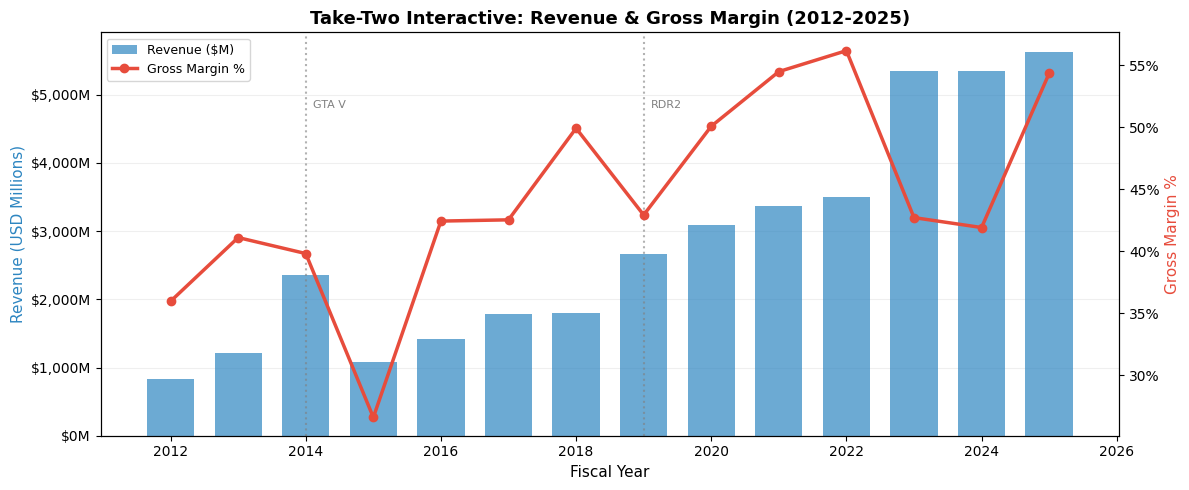

Chart 6 validated


In [9]:
def chart_taketwo_financials(df_fin):
    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax2 = ax1.twinx()

    ax1.bar(df_fin['fiscal_year'], df_fin['total_revenue_usd_millions'],
            color='#2E86C1', alpha=0.7, width=0.7, label='Revenue ($M)', zorder=2)

    ax2.plot(df_fin['fiscal_year'], df_fin['gross_margin_pct'],
             color='#E74C3C', linewidth=2.5, marker='o',
             markersize=6, label='Gross Margin %', zorder=3)

    # Mark GTA V and RDR2 launch years
    for year, label in [(2014, 'GTA V'), (2019, 'RDR2')]:
        ax1.axvline(x=year, color='gray', linestyle=':', alpha=0.6, linewidth=1.5)
        ax1.text(year + 0.1, 4800, label, fontsize=8, color='gray')

    ax1.set_xlabel('Fiscal Year', fontsize=11)
    ax1.set_ylabel('Revenue (USD Millions)', fontsize=11, color='#2E86C1')
    ax2.set_ylabel('Gross Margin %', fontsize=11, color='#E74C3C')
    ax1.set_title('Take-Two Interactive: Revenue & Gross Margin (2012-2025)',
                  fontsize=13, fontweight='bold')

    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

    ax1.grid(axis='y', alpha=0.2)

    plt.tight_layout()
    plt.savefig('../data/processed/chart_taketwo_financials.png', dpi=150, bbox_inches='tight')
    plt.show()

chart_taketwo_financials(df_fin)
print("Chart 6 validated")

## 9. Validation Summary

All charts validated. Ready to promote to app.py.

In [10]:
charts = [
    'chart_price_history.png',
    'chart_inflation_impact.png',
    'chart_publisher_comparison.png',
    'chart_premium_gap.png',
    'chart_prediction.png',
    'chart_taketwo_financials.png'
]

print("Dashboard validation complete")
print()
print("Charts saved to data/processed/:")
for c in charts:
    path = f'../data/processed/{c}'
    exists = os.path.exists(path)
    status = 'OK' if exists else 'MISSING'
    print(f"  [{status}] {c}")

print()
print(f"Final prediction:")
print(f"  GTA VI Base Edition:    ${prediction['pred_nominal']:.2f}")
print(f"  GTA VI Premium Edition: ${prediction['pred_premium']:.2f}")
print(f"  Confidence range:       ${prediction['low']:.2f} - ${prediction['high']:.2f}")
print()
print("Next step: promote all notebooks to production scripts in src/ and build app.py")

Dashboard validation complete

Charts saved to data/processed/:
  [OK] chart_price_history.png
  [OK] chart_inflation_impact.png
  [OK] chart_publisher_comparison.png
  [OK] chart_premium_gap.png
  [OK] chart_prediction.png
  [OK] chart_taketwo_financials.png

Final prediction:
  GTA VI Base Edition:    $69.72
  GTA VI Premium Edition: $93.05
  Confidence range:       $67.37 - $72.07

Next step: promote all notebooks to production scripts in src/ and build app.py
